## PHYS2116 Computational Assessment

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("PS_2026.03.07_22.43.48.csv",comment="#")
# Remove rows with missing values that required
df = df.dropna(subset=['pl_radj', 'pl_bmassj', 'pl_eqt', 'pl_orbper'])
# Filter Hot Jupiters
hot_jupiters = df[(df['pl_bmassj'] > 0.36) & (df['pl_orbper'] < 10) & (df['pl_bmassj'] < 11.8) ]

C:\Users\83639\AppData\Local\Temp\ipykernel_32936\3613871703.py:6: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("PS_2026.03.07_22.43.48.csv",comment="#")


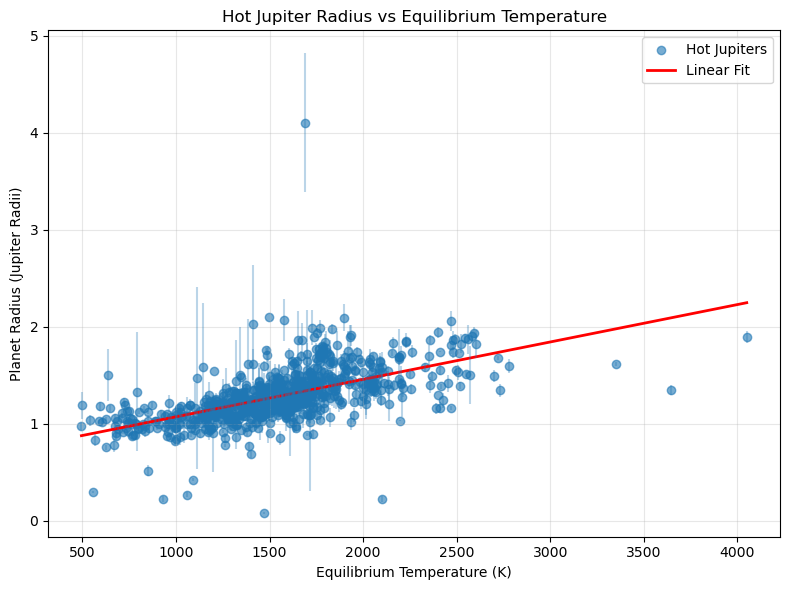

In [2]:
x = hot_jupiters['pl_eqt']
y = hot_jupiters['pl_radj']
m, b = np.polyfit(x, y, 1)
trendline = m*x + b

sorted_idx = np.argsort(x)
x_sorted = x.iloc[sorted_idx]
trend_sorted = (m*x + b).iloc[sorted_idx]

plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.6, label="Hot Jupiters")
plt.plot(x_sorted, trend_sorted, color='red', linewidth=2, label="Linear Fit")
plt.errorbar(hot_jupiters['pl_eqt'], hot_jupiters['pl_radj'], yerr=hot_jupiters['pl_radjerr1'], fmt='none', alpha=0.3)

plt.xlabel("Equilibrium Temperature (K)")
plt.ylabel("Planet Radius (Jupiter Radii)")
plt.title("Hot Jupiter Radius vs Equilibrium Temperature")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.legend()
plt.savefig('RvsT.png')
plt.show()

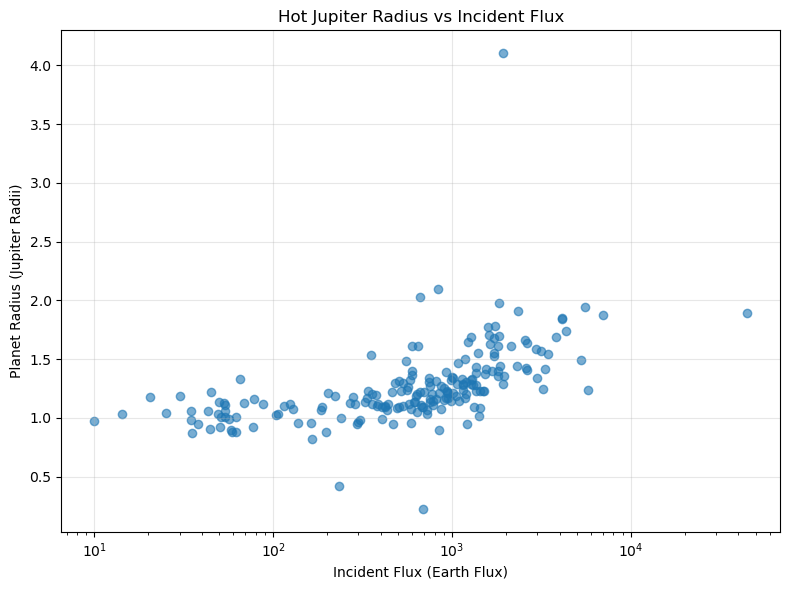

In [7]:
plt.figure(figsize=(8,6))

# remove missing values
flux_data = hot_jupiters.dropna(subset=['pl_insol'])

plt.scatter(flux_data['pl_insol'], flux_data['pl_radj'], alpha=0.6)

plt.xlabel("Incident Flux (Earth Flux)")
plt.ylabel("Planet Radius (Jupiter Radii)")
plt.title("Hot Jupiter Radius vs Incident Flux")
plt.xscale('log')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("RvIF.png")
plt.show()

#### The analysis shows a weak but noticeable correlation between equilibrium temperature and planetary radius. A stronger relationship is observed when considering incident stellar flux, suggesting that stellar irradiation plays a key role in driving radius inflation in hot Jupiter planets. High levels of stellar irradiation deposit energy into the planetary atmosphere, causing it to expand. This results in inflated radii for planets receiving strong stellar flux. However, this analysis is limited by observational uncertainties and incomplete data in the exoplanet archive. Additionally, selection effects may bias the sample toward larger and more easily detectable planets. The use of simple linear models may also not fully capture the underlying physical processes.